In [2]:
from CiCMoments import *
from CountsinCylinders import *

In [19]:
#set up auto-reload for development purposes

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load in tables ##

In [4]:
#randoms
#Counts around randoms, Abacus
ab_randoms_elg = []
ab_randoms_lrg = []
for i in np.arange(7):
    file = "/pscratch/sd/c/crmiller/forFA_countsaroundrandoms_"+str(i)+"R_1"
    elgrand = Table.read(file+"elg_nodownsample.csv",format='csv')
    lrgrand = Table.read(file+"lrg.csv",format='csv')
    ab_randoms_elg.append(elgrand)
    ab_randoms_lrg.append(lrgrand)

In [5]:
#Counts around randoms, SV3
sv3_randoms_elg = []
sv3_randoms_lrg = []
file = "/pscratch/sd/c/crmiller/SV3_countsaroundrandoms_"
elgrand = Table.read(file+"elg.csv",format='csv')
lrgrand = Table.read(file+"lrg.csv",format='csv')

In [6]:
'''#divide random tables into 10 blocks by RA

#hacky solution for the moment because I didn't compute counts around randoms for multiple catalogs
ralim = [130,223]
declim  = [-5.25,3.75]

ras = np.linspace(*ralim, num = 11)
for i in range(10):
    randoms_elg.append(elgrand[(elgrand['RA'] > ras[i])&(elgrand['RA'] < ras[i+1])])
    randoms_lrg.append(lrgrand[(lrgrand['RA'] > ras[i])&(lrgrand['RA'] < ras[i+1])])'''

"#divide random tables into 10 blocks by RA\n\n#hacky solution for the moment because I didn't compute counts around randoms for multiple catalogs\nralim = [130,223]\ndeclim  = [-5.25,3.75]\n\nras = np.linspace(*ralim, num = 11)\nfor i in range(10):\n    randoms_elg.append(elgrand[(elgrand['RA'] > ras[i])&(elgrand['RA'] < ras[i+1])])\n    randoms_lrg.append(lrgrand[(lrgrand['RA'] > ras[i])&(lrgrand['RA'] < ras[i+1])])"

In [7]:
#divide up by rosette
for i in range(20):
    sv3_randoms_elg.append(elgrand[checkAngularSep(elgrand['RA'],rosettes['RA'][i],elgrand['DEC'],rosettes['DEC'][i],0,2)])

In [8]:
#divide up by rosette
for i in range(20):
    sv3_randoms_lrg.append(lrgrand[checkAngularSep(lrgrand['RA'],rosettes['RA'][i],lrgrand['DEC'],rosettes['DEC'][i],0,2)])

## Start here if not using randoms ##

In [9]:
#SV3 counts around galaxies
#sv3elg = Table.read("datafiles/SV3_HIPnotqso_cleaned_R1L40_elg.csv")
#sv3lrg = Table.read("datafiles/SV3_HIPnotqso_cleaned_R1L40_lrg.csv")

sv3elg = Table.read("datafiles/SV3_zboundary_R1L40_elg.csv")
sv3lrg = Table.read("datafiles/SV3_zboundary_R1L40_lrg.csv")

sv3elg_ros = [sv3elg[(sv3elg['rosette'] == i)] for i in np.arange(1,21)]
sv3lrg_ros = [sv3lrg[(sv3lrg['rosette'] == i)] for i in np.arange(1,21)]

#Abacus counts around galaxies
R_CiC = "1"
Abacus_elg = []
Abacus_lrg = []
for mocknumber in np.arange(18):
    tabelg = Table.read("datafiles/forFA_noebits_cleaned_"+str(mocknumber)+"_R1L40_elg.csv",format='csv')
    #tabelg = tabelg[tabelg["RSDZ"] > 0.8]
    Abacus_elg.append(tabelg)
    Abacus_lrg.append(Table.read("datafiles/forFA_noebits_cleaned_"+str(mocknumber)+"_R1L40_lrg.csv",format='csv'))

## Compute number density ##

In [10]:
n_ab = len(Abacus_elg)
solidangle_Abacus_elg = 0.2205489466458694
solidangle_Abacus_lrg = 0.2234280340605831
solidangle_SV3_elg = 0.03693036714443724
solidangle_SV3_lrg = 0.035465953279160425

zlim = [0.80695,0.9919]
nbins= 20

Abacus_elg_nZ, bins = getnZ(Abacus_elg[0], solidangle_Abacus_elg, zlim, nbins, zname = "RSDZ")
Abacus_lrg_nZ, bins = getnZ(Abacus_lrg[0], solidangle_Abacus_lrg, zlim, nbins, zname = 'RSDZ')

sv3_elg_nZ, bins = getnZ(sv3elg, solidangle_SV3_elg, zlim, nbins)
sv3_lrg_nZ, bins = getnZ(sv3lrg, solidangle_SV3_lrg, zlim, nbins)

Vcyl = 1*np.pi*40
ab_rand_elg_nZ,bins = getnZfromNCiC(ab_randoms_elg[0], zlim,nbins,Vcyl,zname = "RSDZ",cicname="N_elgCiC")
ab_rand_lrg_nZ,bins = getnZfromNCiC(ab_randoms_lrg[0], zlim,nbins,Vcyl,zname = "RSDZ",cicname="N_lrgCiC")

sv3_rand_elg_nZ,bins = getnZfromNCiC(elgrand, zlim,nbins,Vcyl,cicname = "N_elgCiC")
sv3_rand_lrg_nZ,bins = getnZfromNCiC(lrgrand, zlim,nbins,Vcyl,cicname="N_lrgCiC")


sv3_elg_nZlist = []
sv3_lrg_nZlist = []

abacus_elg_nZlist = []
abacus_lrg_nZlist = []
for i in range(20):
    sv3_elg_nZlist.append(getnZ(sv3elg_ros[i], solidangle_SV3_elg/20, zlim, nbins)[0])
    sv3_lrg_nZlist.append(getnZ(sv3lrg_ros[i], solidangle_SV3_lrg/20, zlim, nbins)[0])
for i in range(n_ab):
    #abacus_elg_nZlist.append(getnZ(Abacus_elg[i], solidangle_Abacus_elg, zlim, nbins)[0])
    #abacus_lrg_nZlist.append(getnZ(Abacus_lrg[i], solidangle_Abacus_lrg, zlim, nbins)[0])
    abacus_elg_nZlist.append(getnZ(Abacus_elg[i], solidangle_Abacus_elg, zlim, nbins, zname ='RSDZ')[0])
    abacus_lrg_nZlist.append(getnZ(Abacus_lrg[i], solidangle_Abacus_lrg, zlim, nbins, zname = 'RSDZ')[0])


sv3_elg_nzerr = []
sv3_lrg_nzerr = []
for i in range(len(bins)-1):
    sv3_elg_nzerr.append(np.std([sv3_elg_nZlist[j][i] for j in range(20)])/np.sqrt(20))
    sv3_lrg_nzerr.append(np.std([sv3_lrg_nZlist[j][i] for j in range(20)])/np.sqrt(20))

Abacus_elg_nzerr = []
Abacus_lrg_nzerr = []
for i in range(len(bins)-1):
    Abacus_elg_nzerr.append(np.std([abacus_elg_nZlist[j][i] for j in range(n_ab)])/np.sqrt(n_ab))
    Abacus_lrg_nzerr.append(np.std([abacus_lrg_nZlist[j][i] for j in range(n_ab)])/np.sqrt(n_ab))

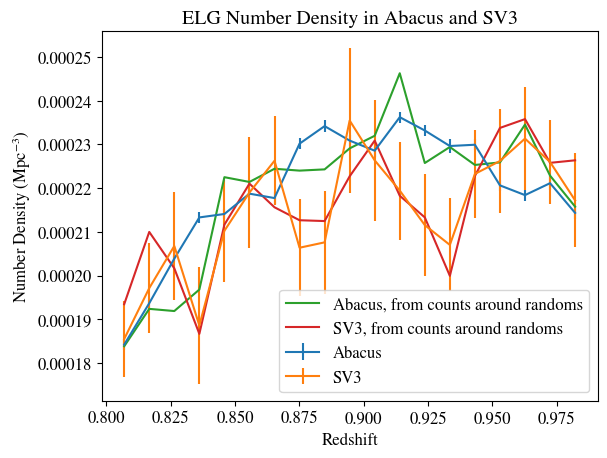

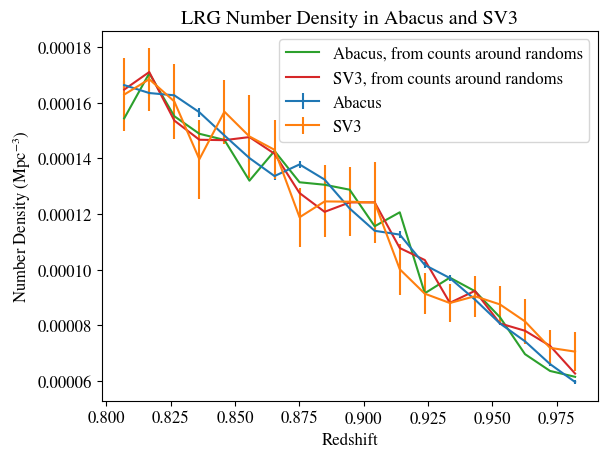

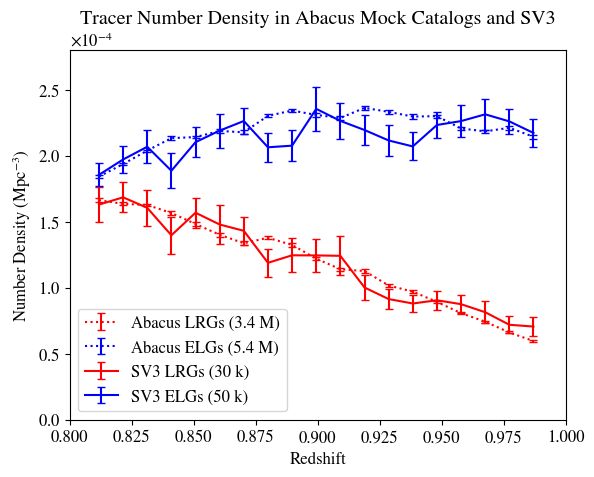

In [11]:
plt.rcParams['font.size'] = 12
plt.errorbar(bins[:-1], Abacus_elg_nZ,yerr = Abacus_elg_nzerr,label="Abacus")
plt.errorbar(bins[:-1], sv3_elg_nZ,yerr = sv3_elg_nzerr,label='SV3')
plt.plot(bins[:-1], ab_rand_elg_nZ,label="Abacus, from counts around randoms")
plt.plot(bins[:-1], sv3_rand_elg_nZ,label="SV3, from counts around randoms")

plt.title("ELG Number Density in Abacus and SV3")
plt.xlabel("Redshift")
plt.ylabel(r"Number Density (Mpc$^{-3}$)")
plt.legend()


plt.figure()
plt.errorbar(bins[:-1], Abacus_lrg_nZ,label='Abacus',yerr = Abacus_lrg_nzerr)
plt.errorbar(bins[:-1], sv3_lrg_nZ,label = 'SV3',yerr = sv3_lrg_nzerr)
plt.plot(bins[:-1], ab_rand_lrg_nZ,label="Abacus, from counts around randoms")
plt.plot(bins[:-1], sv3_rand_lrg_nZ,label="SV3, from counts around randoms")
plt.title("LRG Number Density in Abacus and SV3")
plt.xlabel("Redshift")
plt.ylabel(r"Number Density (Mpc$^{-3}$)")
plt.legend()

plt.figure()
ax = plt.gca()
binstoplot = [(b+b2)/2 for b, b2 in zip(bins[:-1],bins[1:])]
plt.errorbar(binstoplot, Abacus_lrg_nZ,label='Abacus LRGs (3.4 M)',yerr = Abacus_lrg_nzerr,color='red',linestyle = 'dotted',capsize=3)
plt.errorbar(binstoplot, Abacus_elg_nZ,yerr = Abacus_elg_nzerr,label="Abacus ELGs (5.4 M)",color='blue',linestyle='dotted',capsize=3)
plt.errorbar(binstoplot, sv3_lrg_nZ,label = 'SV3 LRGs (30 k)',yerr = sv3_lrg_nzerr, color = 'red',capsize=3)

plt.errorbar(binstoplot, sv3_elg_nZ,yerr = sv3_elg_nzerr,label='SV3 ELGs (50 k)',color='blue',capsize=3)
plt.title("Tracer Number Density in Abacus Mock Catalogs and SV3")
plt.xlabel("Redshift")
plt.ylabel(r"Number Density (Mpc$^{-3}$)")
plt.ylim(0,0.00028)
plt.xlim(0.8,1)
yScalarFormatter = matplotlib.ticker.ScalarFormatter(useMathText=True)
yScalarFormatter.set_powerlimits((0,0))
ax.yaxis.set_major_formatter(yScalarFormatter)
plt.legend(fontsize = 12)
plt.savefig("forpaper/numberdensity.png",dpi=300)

In [55]:
err = 2345
print(f"{err:.0f}")

2345


In [12]:
filetag = "inc_corrected"
correctionratios = Table.read("datafiles/SV3_CiC_correction_ratios.csv")
elgelgweights, lrglrgweights, elglrgweights, lrgelgweights = correctionratios['elgelg'], correctionratios['lrglrg'], correctionratios['elglrg'], correctionratios['lrgelg']

In [13]:
Abacus_elg_hist = CiCHistnZ(Abacus_elg,elgname = "N_CiC",zname='RSDZ',elgweights=elgelgweights,lrgweights=elglrgweights)
Abacus_lrg_hist = CiCHistnZ(Abacus_lrg,lrgname = "N_CiC",zname='RSDZ',elgweights=lrgelgweights,lrgweights=lrglrgweights)

/global/u1/c/crmiller/CiC/CiCMoments.py:33: RuntimeWarning: invalid value encountered in multiply
  self.hists = [np.histogramdd((table[elgname],table[lrgname],table[zname]),bins = bins)[0]*incompletenessweights[:,:,np.newaxis]
/global/u1/c/crmiller/CiC/CiCMoments.py:36: RuntimeWarning: invalid value encountered in multiply
  self.histsum = np.histogramdd((alltab[elgname],alltab[lrgname],alltab[zname]),bins = bins)[0]*incompletenessweights[:,:,np.newaxis]


In [14]:
SV3_elg_hist = CiCHistnZ(sv3elg_ros,elgname = "N_CiC",elgweights=elgelgweights,lrgweights=elglrgweights)
SV3_lrg_hist = CiCHistnZ(sv3lrg_ros,lrgname = "N_CiC",elgweights=lrgelgweights,lrgweights=lrglrgweights)

In [15]:
Abacus_elg_randhist = CiCHistnZ(ab_randoms_elg,elgname = "N_elgCiC",zname='RSDZ',elgweights=elgelgweights,lrgweights=elglrgweights)
Abacus_lrg_randhist = CiCHistnZ(ab_randoms_lrg,lrgname = "N_lrgCiC",zname='RSDZ',elgweights=lrgelgweights,lrgweights=lrglrgweights)

In [16]:
SV3_elg_randhist = CiCHistnZ(sv3_randoms_elg,elgname = "N_elgCiC",elgweights=elgelgweights,lrgweights=elglrgweights)
SV3_lrg_randhist = CiCHistnZ(sv3_randoms_lrg,lrgname = "N_lrgCiC",elgweights=lrgelgweights,lrgweights=lrglrgweights)

In [20]:
ab_elg_momsimple = Abacus_elg_hist.makeMomentTable(3, momentSimple,filename = "ab_elg_momsimple"+filetag+".ecsv")
ab_lrg_momsimple = Abacus_lrg_hist.makeMomentTable(3, momentSimple,filename = "ab_lrg_momsimple"+filetag+".ecsv")


sv3_elg_momsimple = SV3_elg_hist.makeMomentTable(3, momentSimple,filename = "sv3_elg_momsimple"+filetag+".ecsv") #,savesubsamples=True)
sv3_lrg_momsimple = SV3_lrg_hist.makeMomentTable(3, momentSimple,filename = "sv3_lrg_momsimple"+filetag+".ecsv") #,savesubsamples=True)

saved file ab_elg_momsimpleinc_corrected.ecsv
saved file ab_lrg_momsimpleinc_corrected.ecsv
saved file sv3_elg_momsimpleinc_corrected.ecsv
saved file sv3_lrg_momsimpleinc_corrected.ecsv


In [21]:
compelg_simple = momentRatio(ab_elg_momsimple,sv3_elg_momsimple)
complrg_simple = momentRatio(ab_lrg_momsimple,sv3_lrg_momsimple)

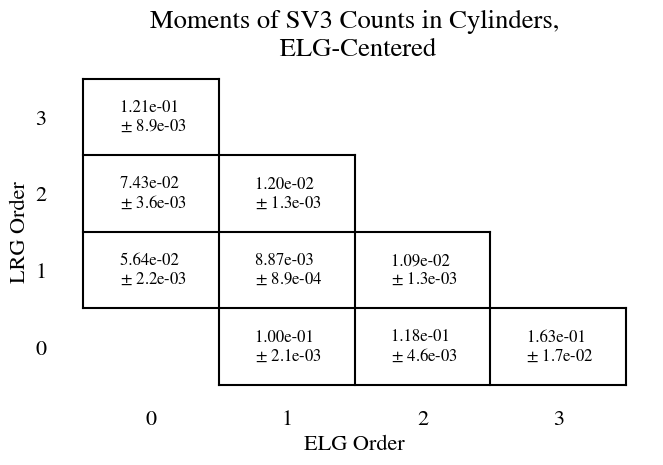

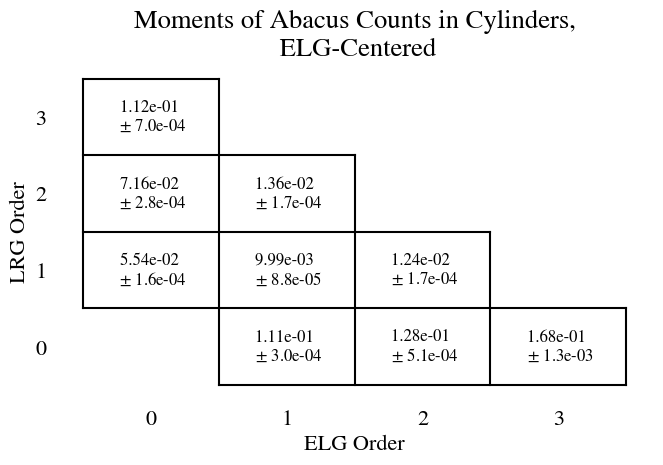

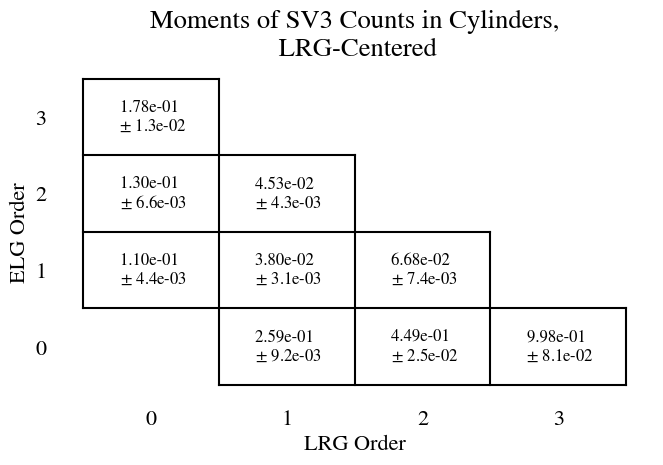

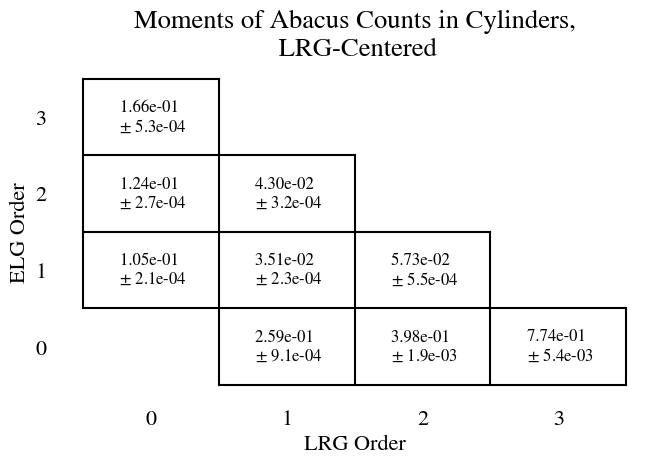

In [23]:
showMomentTable(sv3_elg_momsimple,title = "Moments of SV3 Counts in Cylinders,\n ELG-Centered",filename="momentfigs/simpleELG_sv3")
showMomentTable(ab_elg_momsimple,title = "Moments of Abacus Counts in Cylinders,\n ELG-Centered",filename="momentfigs/simpleELG_abacus")

showMomentTable(sv3_lrg_momsimple,lrg=True,title = "Moments of SV3 Counts in Cylinders,\n LRG-Centered",filename="momentfigs/simpleLRG_sv3")
showMomentTable(ab_lrg_momsimple,lrg=True,title = "Moments of Abacus Counts in Cylinders,\n LRG-Centered",filename="momentfigs/simpleLRG_abacus")

In [24]:
#showMomentTable(compelg_simple,title = "Ratio of Moments of Abacus and SV3 Counts in Cylinders,\n ELG-Centered",scientific = False,filename="momentfigs/simpleELG")
#showMomentTable(complrg_simple,title = "Ratio of Moments of Abacus and SV3 Counts in Cylinders,\n LRG-Centered",scientific = False,lrg=True,filename="momentfigs/simpleLRG")

In [25]:
ab_elg_momfactorial = Abacus_elg_hist.makeMomentTable(3, factorialMoment, filename = 'ab_elg_momfactorial'+filetag+'.ecsv')
ab_lrg_momfactorial = Abacus_lrg_hist.makeMomentTable(3, factorialMoment, filename = 'ab_lrg_momfactorial'+filetag+'.ecsv')


sv3_elg_momfactorial = SV3_elg_hist.makeMomentTable(3, factorialMoment, filename = 'sv3_elg_momfactorial'+filetag+'.ecsv')
sv3_lrg_momfactorial = SV3_lrg_hist.makeMomentTable(3, factorialMoment, filename = 'sv3_lrg_momfactorial'+filetag+'.ecsv')

saved file ab_elg_momfactorialinc_corrected.ecsv
saved file ab_lrg_momfactorialinc_corrected.ecsv
saved file sv3_elg_momfactorialinc_corrected.ecsv
saved file sv3_lrg_momfactorialinc_corrected.ecsv


In [26]:
compelg_factorial = momentRatio(ab_elg_momfactorial,sv3_elg_momfactorial)
complrg_factorial = momentRatio(ab_lrg_momfactorial,sv3_lrg_momfactorial)

In [27]:
#showMomentTable(compelg_factorial,title = "Ratio of Factorial Moments of Abacus and SV3 Counts in Cylinders,\n ELG-Centered",scientific = False,filename="momentfigs/factorialELG"+filetag)
#showMomentTable(complrg_factorial,title = "Ratio of Factorial Moments of Abacus and SV3 Counts in Cylinders,\n LRG-Centered",scientific = False,lrg=True,filename="momentfigs/factorialLRG"+filetag)

In [41]:
Vcyl = 1*np.pi*40
extraargs = [Vcyl,Abacus_elg_nZ,Abacus_lrg_nZ]

ab_elg_ntilde = Abacus_elg_hist.makeMomentTable(3, Ntilde,extraargs = extraargs, filename = 'ab_elg_ntilde'+filetag+'.ecsv')
ab_lrg_ntilde = Abacus_lrg_hist.makeMomentTable(3, Ntilde,extraargs = extraargs, filename = 'ab_lrg_ntilde'+filetag+'.ecsv')

extraargs = [Vcyl,sv3_elg_nZ,sv3_lrg_nZ]
sv3_elg_ntilde = SV3_elg_hist.makeMomentTable(3, Ntilde,extraargs = extraargs, filename = 'sv3_elg_ntilde'+filetag+'.ecsv')
sv3_lrg_ntilde = SV3_lrg_hist.makeMomentTable(3, Ntilde,extraargs = extraargs, filename = 'sv3_lrg_ntilde'+filetag+'.ecsv')

compelg_ntilde = momentRatio(ab_elg_ntilde,sv3_elg_ntilde)
complrg_ntilde = momentRatio(ab_lrg_ntilde,sv3_lrg_ntilde)

saved file ab_elg_ntildeinc_corrected.ecsv
saved file ab_lrg_ntildeinc_corrected.ecsv
saved file sv3_elg_ntildeinc_corrected.ecsv
saved file sv3_lrg_ntildeinc_corrected.ecsv


In [42]:
'''extraargs = [Vcyl,sv3_elg_nZ,sv3_lrg_nZ]
sv3_elg_ntilde = SV3_elg_hist.makeMomentTable(3, Ntilde,extraargs = extraargs, savesubsamples = True)'''

'extraargs = [Vcyl,sv3_elg_nZ,sv3_lrg_nZ]\nsv3_elg_ntilde = SV3_elg_hist.makeMomentTable(3, Ntilde,extraargs = extraargs, savesubsamples = True)'

In [43]:
"""extraargs = [Vcyl,sv3_elg_nZ,sv3_lrg_nZ]
sv3_lrg_ntilde = SV3_lrg_hist.makeMomentTable(3, Ntilde,extraargs = extraargs, savesubsamples = True)"""

'extraargs = [Vcyl,sv3_elg_nZ,sv3_lrg_nZ]\nsv3_lrg_ntilde = SV3_lrg_hist.makeMomentTable(3, Ntilde,extraargs = extraargs, savesubsamples = True)'

In [44]:
Vcyl = 1*np.pi*40
#extraargs = [Vcyl,Abacus_elg_nZ,Abacus_lrg_nZ]
abran_elg_momsimple = Abacus_elg_randhist.makeMomentTable(3, momentSimple, filename='abran_elg_momsimple'+filetag+'.ecsv')
abran_lrg_momsimple = Abacus_lrg_randhist.makeMomentTable(3, momentSimple,filename='abran_lrg_momsimple'+filetag+'.ecsv')

#extraargs = [Vcyl,sv3_elg_nZ,sv3_lrg_nZ]
sv3ran_elg_momsimple = SV3_elg_randhist.makeMomentTable(3, momentSimple, filename='sv3ran_elg_momsimple'+filetag+'.ecsv',savesubsamples = True)
sv3ran_lrg_momsimple = SV3_lrg_randhist.makeMomentTable(3, momentSimple, filename='sv3ran_lrg_momsimple'+filetag+'.ecsv',savesubsamples = True)

saved file abran_elg_momsimpleinc_corrected.ecsv
saved file abran_lrg_momsimpleinc_corrected.ecsv
saved file sv3ran_elg_momsimpleinc_corrected.ecsv
saved file sv3ran_lrg_momsimpleinc_corrected.ecsv


In [29]:
#showMomentTable(abran_elg_momsimple,title="Moments of Abacus Random-Centered Counts")
#showMomentTable(sv3ran_elg_momsimple,title="Moments of SV3 Random-Centered Counts")
#print(np.average(

In [30]:
#showMomentTable(ab_elg_momfactorial,title = r"Factorial Moments of Abacus Counts in Cylinders,"+"\n ELG-Centered",filename="momentfigs/factorial_ab_ELG")
#showMomentTable(sv3_elg_momfactorial,title = r"Factorial Moments of SV3 Counts in Cylinders,"+"\n ELG-Centered",filename="momentfigs/factorial_sv3_elg")

In [31]:
#showMomentTable(ab_elg_ntilde,title = r"$\left<\tilde{N}\right>$ in Abacus Counts in Cylinders,"+"\n ELG-Centered",filename="momentfigs/ntilde_ab_ELG")
#showMomentTable(sv3_elg_ntilde,title = r"$\left<\tilde{N}\right>$ in SV3 Counts in Cylinders,"+"\n ELG-Centered",filename="momentfigs/ntilde_sv3_elg")

In [32]:
#showMomentTable(compelg_ntilde,title = r"Ratio of $\left<\tilde{N}\right>$ in Abacus and SV3 Counts in Cylinders,"+"\n ELG-Centered",scientific = False,filename="momentfigs/ntildeELG")
#showMomentTable(complrg_ntilde,title = r"Ratio of $\left<\tilde{N}\right>$ in Abacus and SV3 Counts in Cylinders,"+"\n LRG-Centered",scientific = False,lrg=True,filename="momentfigs/ntildeLRG")

In [33]:
#showMomentTable(ab_elg_ntilde,title = r"$\left<\tilde{N}\right>$ in Abacus Counts in Cylinders,"+"\n ELG-Centered",filename="momentfigs/ntildeELG_abacus")
#showMomentTable(sv3_elg_ntilde,title = r"$\left<\tilde{N}\right>$ in SV3 Counts in Cylinders,"+"\n ELG-Centered",filename="momentfigs/ntildeELG_sv3")

In [34]:
#showMomentTable(ab_lrg_ntilde,title = r"$\left<\tilde{N}\right>$ in Abacus Counts in Cylinders,"+"\n LRG-Centered",lrg=True,filename="momentfigs/ntildeLRG_abacus")
#showMomentTable(sv3_lrg_ntilde,title = r"$\left<\tilde{N}\right>$ in SV3 Counts in Cylinders,"+"\n LRG-Centered",lrg=True,filename="momentfigs/ntildeLRG_sv3")

In [35]:
Vcyl = 1*np.pi*40
extraargs = [Vcyl,Abacus_elg_nZ,Abacus_lrg_nZ]
abran_elg_ntilde = Abacus_elg_randhist.makeMomentTable(3, Ntilde,extraargs = extraargs, filename='abran_elg_ntilde'+filetag+'.ecsv')
abran_lrg_ntilde = Abacus_lrg_randhist.makeMomentTable(3, Ntilde,extraargs = extraargs,filename='abran_lrg_ntilde'+filetag+'.ecsv')

extraargs = [Vcyl,sv3_elg_nZ,sv3_lrg_nZ]
sv3ran_elg_ntilde = SV3_elg_randhist.makeMomentTable(3, Ntilde,extraargs = extraargs,filename='sv3ran_elg_ntilde'+filetag+'.ecsv')
sv3ran_lrg_ntilde = SV3_lrg_randhist.makeMomentTable(3, Ntilde,extraargs = extraargs,filename='sv3ran_lrg_ntilde'+filetag+'.ecsv')

saved file abran_elg_ntildeinc_corrected.ecsv
saved file abran_lrg_ntildeinc_corrected.ecsv
saved file sv3ran_elg_ntildeinc_corrected.ecsv
saved file sv3ran_lrg_ntildeinc_corrected.ecsv


In [45]:
Vcyl = 1*np.pi*40
extraargs = [Abacus_elg_nZ,Abacus_lrg_nZ]
ab_elg_nz = Abacus_elg_hist.makeMomentTable(3, nZintegral,extraargs = extraargs,filename="ab_elg_nz"+filetag+".ecsv")
ab_lrg_nz = Abacus_lrg_hist.makeMomentTable(3, nZintegral,extraargs = extraargs,filename="ab_lrg_nz"+filetag+".ecsv")

extraargs = [sv3_elg_nZ,sv3_lrg_nZ]
sv3_elg_nz = SV3_elg_hist.makeMomentTable(3, nZintegral,extraargs = extraargs,filename="sv3_elg_nz"+filetag+".ecsv")
sv3_lrg_nz = SV3_lrg_hist.makeMomentTable(3, nZintegral,extraargs = extraargs,filename="sv3_lrg_nz"+filetag+".ecsv")

saved file ab_elg_nzinc_corrected.ecsv
saved file ab_lrg_nzinc_corrected.ecsv
saved file sv3_elg_nzinc_corrected.ecsv
saved file sv3_lrg_nzinc_corrected.ecsv


In [37]:
#showMomentTable(ab_elg_nz)
#showMomentTable(sv3_elg_nz)

In [47]:
Vcyl = 1*np.pi*40
extraargs = [Vcyl]
ab_elg_vcyl = Abacus_elg_hist.makeMomentTable(3, vCylPower,extraargs = extraargs, filename = "ab_elg_vcyl"+filetag+".ecsv")
ab_lrg_vcyl = Abacus_lrg_hist.makeMomentTable(3, vCylPower,extraargs = extraargs, filename = "ab_lrg_vcyl"+filetag+".ecsv")

extraargs = [Vcyl]
sv3_elg_vcyl = SV3_elg_hist.makeMomentTable(3, vCylPower,extraargs = extraargs, filename = "sv3_elg_vcyl"+filetag+".ecsv")
sv3_lrg_vcyl = SV3_lrg_hist.makeMomentTable(3, vCylPower,extraargs = extraargs, filename = "sv3_lrg_vcyl"+filetag+".ecsv")

saved file ab_elg_vcylinc_corrected.ecsv
saved file ab_lrg_vcylinc_corrected.ecsv
saved file sv3_elg_vcylinc_corrected.ecsv
saved file sv3_lrg_vcylinc_corrected.ecsv


In [48]:
def avgnpcf(tab_ntilde_dat,tab_ntilde_ran,tab_nz,tab_vcyl):
    tab_npcf = Table()
    tab_npcf["ELG Order, LRG Order"] = tab_ntilde_dat["ELG Order, LRG Order"]
    tab_npcf["Moment"] = (tab_ntilde_dat["Moment"]-tab_ntilde_ran["Moment"])/(tab_nz["Moment"]*tab_vcyl["Moment"])
    tab_npcf["Standard Error"] = np.sqrt((tab_ntilde_dat["Standard Error"]/(tab_nz["Moment"]*tab_vcyl["Moment"]))**2 \
                           + (tab_ntilde_ran["Standard Error"]/(tab_nz["Moment"]*tab_vcyl["Moment"]))**2 \
                                         +(tab_nz["Standard Error"]/tab_nz["Moment"])**2)
    return tab_npcf

In [49]:
sv3_elg_npcf = avgnpcf(sv3_elg_ntilde,sv3ran_elg_ntilde,sv3_elg_nz,sv3_elg_vcyl)
sv3_lrg_npcf = avgnpcf(sv3_lrg_ntilde,sv3ran_lrg_ntilde,sv3_lrg_nz,sv3_lrg_vcyl)

ab_elg_npcf = avgnpcf(ab_elg_ntilde,abran_elg_ntilde,ab_elg_nz,ab_elg_vcyl)
ab_lrg_npcf = avgnpcf(ab_lrg_ntilde,abran_lrg_ntilde,ab_lrg_nz,ab_elg_vcyl)

In [50]:
#showMomentTable(sv3_elg_npcf,title = r"$\bar{\xi}$ in SV3, ELG-Centered",filename="momentfigs/xibarelg_sv3")
#showMomentTable(ab_elg_npcf,title = r"$\bar{\xi}$ in Abacus, ELG-Centered",filename="momentfigs/xibarab_sv3")

In [51]:
#showMomentTable(sv3_lrg_npcf,title = r"$\bar{\xi}$ in SV3, LRG-Centered",filename="momentfigs/xibarlrg_ab",lrg= True)
#showMomentTable(ab_lrg_npcf,title = r"$\bar{\xi}$ in Abacus, LRG-Centered",filename="momentfigs/xibarlrg_ab",lrg=True)

In [50]:
print(sv3_elg_nz)

ELG Order, LRG Order         Moment             Standard Error    
-------------------- ---------------------- ----------------------
              0 .. 1 0.00011576175665930848  5.079019269118472e-07
              0 .. 2 1.4396817465201391e-08 1.1728063658432112e-10
              0 .. 3  1.901795475941514e-12 2.1390292992052074e-14
              1 .. 0 0.00021562062312423472 2.2049171993002635e-07
              1 .. 1  2.475475429002454e-08 1.0209767782580497e-10
              1 .. 2 3.0531811384261264e-12 2.3723902656084476e-14
              2 .. 0  4.666212950105029e-08  9.412913942189913e-11
              2 .. 1  5.315709627820657e-12  2.228698282723556e-14
              3 .. 0  1.013316252817378e-11  3.025415291201788e-14


In [51]:
0.00399*125.6

0.5011439999999999

In [52]:
print(ab_elg_vcyl)

ELG Order, LRG Order       Moment           Standard Error    
-------------------- ------------------ ----------------------
              0 .. 1 125.66370614359165 1.6102538999477123e-14
              0 .. 2 15791.367041742964 1.8770127019006105e-12
              0 .. 3 1984401.7075391882 2.5642709291228366e-10
              1 .. 0 125.66370614359165 1.6102538999477123e-14
              1 .. 1 15791.367041742964 1.8770127019006105e-12
              1 .. 2 1984401.7075391882 2.5642709291228366e-10
              2 .. 0 15791.367041742964 1.8770127019006105e-12
              2 .. 1 1984401.7075391882 2.5642709291228366e-10
              3 .. 0 1984401.7075391882 2.5642709291228366e-10


In [53]:
def formatMoment(table, index, scientific = False):
    m = table["Moment"][index]
    err = table["Standard Error"][index]
    string = ''
    if scientific:
        string += f"{m:.2e} "+r"$\pm$"+f" {err:.1e}"
    else: 
        string += f"{m:.3f} \n "+r"$\pm$"+f" {err:.3f}"
    return string

def printMomentTableLaTeX(table,captiontxt,lrg = False,scientific = False):
    #so hacky but whatever
    if lrg:
        ix = [3,6,8,0,4,7,1,5,2]
    else:
        ix = np.arange(9)
    string = r'''
    \begin{table}
    \caption{''' + captiontxt + r'''}
    \begin{tabular}{ |c  |c  |c  |c|c |c|}
    \cline{3-6}
    \multicolumn{2}{c}{}&\multicolumn{4}{|c|}{'''+("ELG Order" if lrg else "LRG Order")+r'''}\\\cline{3-6}
     \multicolumn{1}{c}{}& &  0&1&  2 &3\\[2pt] \hline
    
    \multirow[|l|]{4}{*}{\rotatebox[origin=c]{90}{'''+("LRG Order" if lrg else "ELG Order")+r'''}}& \multicolumn{1}{|c|}{0} && ''' \
    + formatMoment(table,ix[0]) + r''' & ''' + formatMoment(table,ix[1]) + r"&" + formatMoment(table,ix[2]) \
    + r"\\[2pt]" \
    + r'''\cline{2-6}
     & \multicolumn{1}{|c|}{1} &''' +formatMoment(table,ix[3]) +"&" + formatMoment(table,ix[4]) +"&" + formatMoment(table,ix[5]) + r'''&\multicolumn{1}{|c}{}\\[2pt]
    \cline{2-5}
     &\multicolumn{1}{|c|}{2} & ''' + formatMoment(table,ix[6]) + "&" +formatMoment(table,ix[7]) + r'''& \multicolumn{2}{|c}{}\\[2pt] \cline{2-4}
     &\multicolumn{1}{|c|}{3} &''' +formatMoment(table,ix[8]) + r'''& \multicolumn{2}{|c}{}\\[2pt] \cline{1-3}
    
    \end{tabular}
    
    \end{table}'''
    return string

In [54]:
string1 = printMomentTableLaTeX(ab_elg_momsimple,"Moments of ELG Counts in Cylinders in Abacus Mock Catalogs")

In [55]:
print(string1)


    \begin{table}
    \caption{Moments of ELG Counts in Cylinders in Abacus Mock Catalogs}
    \begin{tabular}{ |c  |c  |c  |c|c |c|}
    \cline{3-6}
    \multicolumn{2}{c}{}&\multicolumn{4}{|c|}{LRG Order}\\\cline{3-6}
     \multicolumn{1}{c}{}& &  0&1&  2 &3\\[2pt] \hline
    
    \multirow[|l|]{4}{*}{\rotatebox[origin=c]{90}{ELG Order}}& \multicolumn{1}{|c|}{0} && 0.053 
 $\pm$ 0.000 & 0.068 
 $\pm$ 0.000&0.108 
 $\pm$ 0.001\\[2pt]\cline{2-6}
     & \multicolumn{1}{|c|}{1} &0.104 
 $\pm$ 0.000&0.009 
 $\pm$ 0.000&0.012 
 $\pm$ 0.000&\multicolumn{1}{|c}{}\\[2pt]
    \cline{2-5}
     &\multicolumn{1}{|c|}{2} & 0.119 
 $\pm$ 0.000&0.011 
 $\pm$ 0.000& \multicolumn{2}{|c}{}\\[2pt] \cline{2-4}
     &\multicolumn{1}{|c|}{3} &0.152 
 $\pm$ 0.001& \multicolumn{2}{|c}{}\\[2pt] \cline{1-3}
    
    \end{tabular}
    
    \end{table}
